In [ ]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *
from scripts.utils import is_hermitian


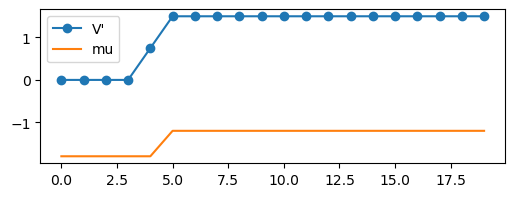

In [15]:
widthN = 5
widthP = 15

X, Y = widthN+widthP, 100
lattice = Lattice(X, Y)
t = 1
T = 0.0
muN = -1.2 * t
muP = -1.8 * t
mu = np.zeros(lattice.X)
mu[widthN:] = muN
mu[:widthN] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
U[widthN-1] = U[widthN-1]/2
U=None

V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 
V[widthN-1] = V[widthN]/2
V=None

V_prime = V0 * np.ones(lattice.X)
V_prime[:widthN] = 0
V_prime[widthN-1] = V_prime[widthN]/2
# V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [16]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V, Fuu_init=[0.01, -0.01, 0.01j, -0.01j], Fdd_init=[0.01, -0.01, 0.01j, -0.01j])


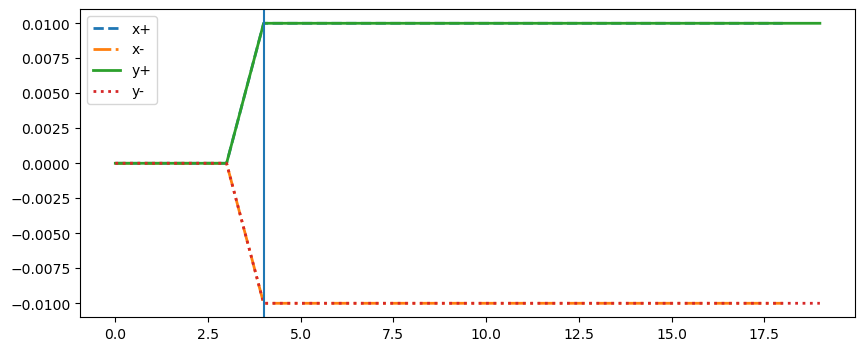

In [17]:
plt.figure(figsize=(10,4))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [18]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))

True
True


In [19]:
bdg_self_consistency(H, temperature=0.0, maxiter=100, atol=1e-3, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 1.1840506644651848e-17
Relative error: 1.184050664465185e-05
Average_old: 0j
Average_new: (-1.0894759840207168e-18+0j)
F_xplus:
Absolute error: 9.390819037932655e-18
Relative error: 9.390819037932655e-06
Average_old: 0j
Average_new: (1.0975652033862598e-18+0j)
F_xmin:
Absolute error: 1.4767226680553864e-17
Relative error: 1.4767226680553866e-05
Average_old: 0j
Average_new: (-2.7040342615199127e-19+0j)
F_yplus:
Absolute error: 1.103027760977057e-17
Relative error: 1.103027760977057e-05
Average_old: 0j
Average_new: (-4.869166849140073e-19-8.7880492441086e-19j)
F_ymin:
Absolute error: 1.103027760977057e-17
Relative error: 1.103027760977057e-05
Average_old: 0j
Average_new: (-4.869166849140073e-19+8.7880492441086e-19j)
Fuu_xplus:
Absolute error: 0.03872983346207417
Relative error: 3.872983345820778
Average_old: (0.007894736842105263+0j)
Average_new: (-7.568194294389496e-21+0j)
Fuu_xmin:
Absolute error: 0.03872983346207417
Relative error: 3.8729833465973775
A

In [20]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [21]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = Fuu_xplus      # site i gets bond (i,i+1)
Fx_m[1:]  = Fuu_xmin       # site i gets bond (i,i-1).T

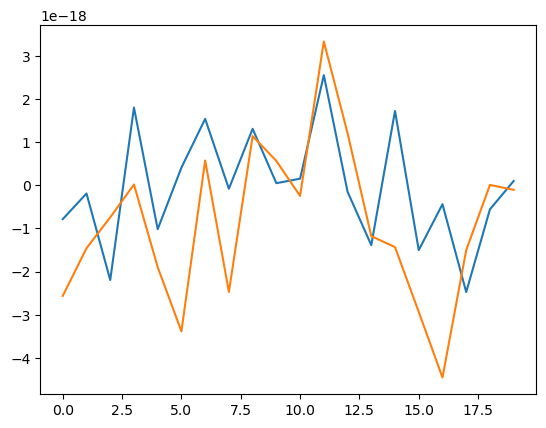

In [22]:
plt.plot(np.real(Fx_p - Fx_m)/2)
plt.plot(np.imag(F_yplus - F_ymin)/2)
# plt.plot(np.real(F0))
# plt.plot(F0)
# plt.plot((Fx_p + Fx_m - F_yplus - F_ymin)/4)

In [23]:
from operator import add, sub
t1 = (1, 3, 3)
t2 = (4, 5, 6)
t1 = tuple(map(add, t1, t2))
print(t1)
t1 = tuple(map(sub, t1, t1))
print(t1)


(5, 8, 9)
(0, 0, 0)
